## Part 2 - IPL Game Comparision

Generate the plots for the pair of games between

a) Kings XI Punjab and Delhi Daredevils

b) Kolkata Knight Riders and Royal Challengers Bangalore

c) Sunrisers and Rajasthan Royals

d) Chennai Super Kings and Kolkata Knight Riders

In [1]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Import IPL ball by ball dataset

IPLbyb = pd.read_excel('/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 1 - Foundations of Sports Analytics: Data, Representation, and Models in Sports/Week 3 Content/Week 3 Assignment: Part 2/IPLbyb (1).xlsx')
print(IPLbyb.columns.tolist())

['home team', 'batting_team', 'bowling_team', 'gameno', 'innings_number', 'over_no', 'ball_no', 'runs_total_end', 'delivery_no', 'delno^2', 'runs*wkts', 'wicket', 'wkts_total_end']


In [4]:
# First, the function for plotting the runs and wickets for each team in a game.

def plot_runs_wickets(IPLbyb, ax):
    gameno = IPLbyb['gameno'].unique()[0]
    for inning, data in IPLbyb.groupby('innings_number'):
        # create separate dataframe for wickets
        wicket = data[data['wicket'] > 0]
        # plots line
        ax.plot(data['delivery_no'],data['runs_total_end'])
        # plots markers
        marker = 'bo' if inning == 1 else 'ro'
        ax.plot(wicket['delivery_no'],wicket['runs_total_end'], marker)
        # labels
        ax.set_xlabel('balls')
        ax.set_ylabel('runs')
        ax.set_title(f'Game {gameno}')
    ax.legend(['runs1','wkt1','runs2','wkt2'])

In [5]:
# Second, a function that allows us to plot two or more games at the same time.

def plot_runs_wickets_multi_game(list_games):
    n = len(list_games)
    fig, axs = plt.subplots(n, 1, figsize=(6,15))
    for i, gameno in enumerate(list_games):
        game = IPLbyb[IPLbyb['gameno'] == gameno]
        plot_runs_wickets(game, axs[i] if n > 1 else axs)

In [6]:
# Identify if the home team batted first

IPLbyb['hometeambatsfirst']= np.where((IPLbyb['home team']==IPLbyb['batting_team']) & (IPLbyb['innings_number']==1),'yes','no')
IPLbyb

,home team,batting_team,bowling_team,gameno,innings_number,over_no,ball_no,runs_total_end,delivery_no,delno^2,runs*wkts,wicket,wkts_total_end,hometeambatsfirst
0,Mumbai Indians,Mumbai Indians,Chennai Super Kings,1,1,0,1,0,1,1,0,0,0,yes
1,Mumbai Indians,Mumbai Indians,Chennai Super Kings,1,1,0,2,0,2,4,0,0,0,yes
2,Mumbai Indians,Mumbai Indians,Chennai Super Kings,1,1,0,3,0,3,9,0,0,0,yes
3,Mumbai Indians,Mumbai Indians,Chennai Super Kings,1,1,0,4,4,4,16,0,0,0,yes
4,Mumbai Indians,Mumbai Indians,Chennai Super Kings,1,1,0,5,5,5,25,0,0,0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14281,Chennai Super Kings,Chennai Super Kings,Sunrisers,60,2,17,5,177,110,12100,354,0,2,no
14282,Chennai Super Kings,Chennai Super Kings,Sunrisers,60,2,17,6,177,111,12321,354,0,2,no
14283,Chennai Super Kings,Chennai Super Kings,Sunrisers,60,2,18,1,177,112,12544,354,0,2,no
14284,Chennai Super Kings,Chennai Super Kings,Sunrisers,60,2,18,2,177,113,12769,354,0,2,no


In [7]:
# drop duplicates so we just have a list of games

games = IPLbyb.drop_duplicates('gameno')

In [8]:
# generate list of games

games = games[['gameno','home team','batting_team','bowling_team','hometeambatsfirst']]
games['road team'] = games.apply(lambda x: x['batting_team'] if x['home team'] == x['bowling_team'] else x['bowling_team'], axis=1)
assert (games['home team'] != games['road team']).all()
games = games[['gameno','home team','road team','hometeambatsfirst']]
games

,gameno,home team,road team,hometeambatsfirst
0,1,Mumbai Indians,Chennai Super Kings,yes
246,2,Kings XI Punjab,Delhi Daredevils,no
484,3,Kolkata Knight Riders,Royal Challengers Bangalore,no
728,4,Sunrisers,Rajasthan Royals,no
953,5,Chennai Super Kings,Kolkata Knight Riders,no
1199,6,Rajasthan Royals,Delhi Daredevils,yes
1345,7,Sunrisers,Mumbai Indians,no
1590,8,Royal Challengers Bangalore,Kings XI Punjab,no
1827,9,Mumbai Indians,Delhi Daredevils,yes
2073,10,Kolkata Knight Riders,Sunrisers,yes


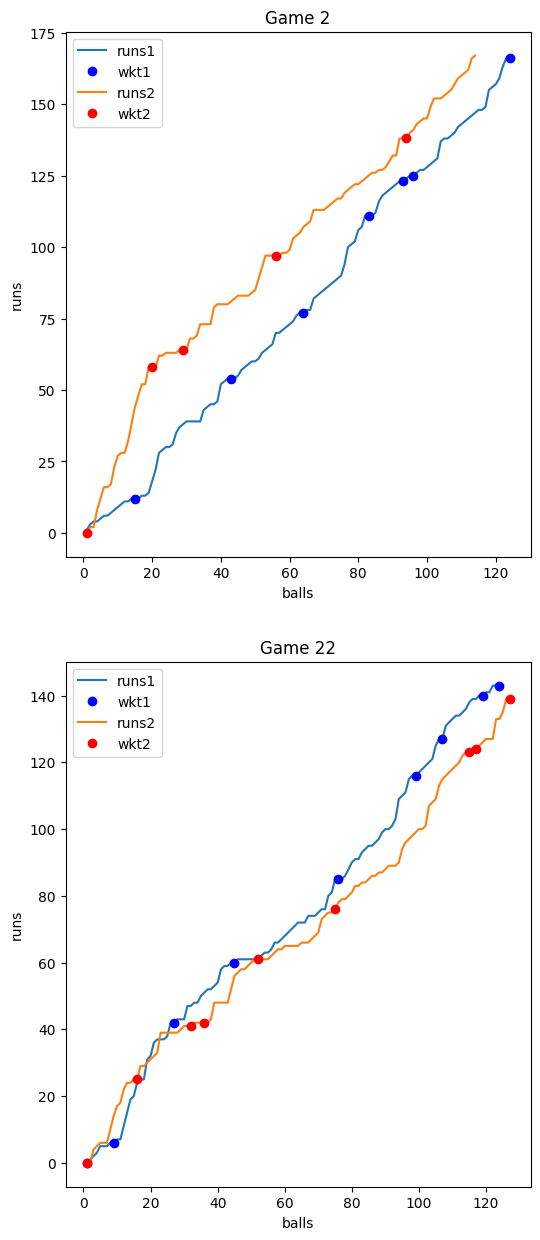

In [9]:
# Generate pair of games between Kings XI Punjab and Delhi Daredevils
plot_runs_wickets_multi_game([2,22])

In game 2, the scoring for the team in inning 2 (Kings XI Punjab) shoots up early until about ball 20 which they lose their second wicket.  There was no looking back from there because the rates stayed pretty constant giving the Kings the home win.

In game 22, the team rates are pretty similar.  The lead go back and forth multiple times up until around ball 30.  From then on the first inning team (Kings XI Punjab) take over and score about 145 runs which is enough to hold off the Daredevils.  The Kings win again giving them the season sweep over the Dehli Daredevils.

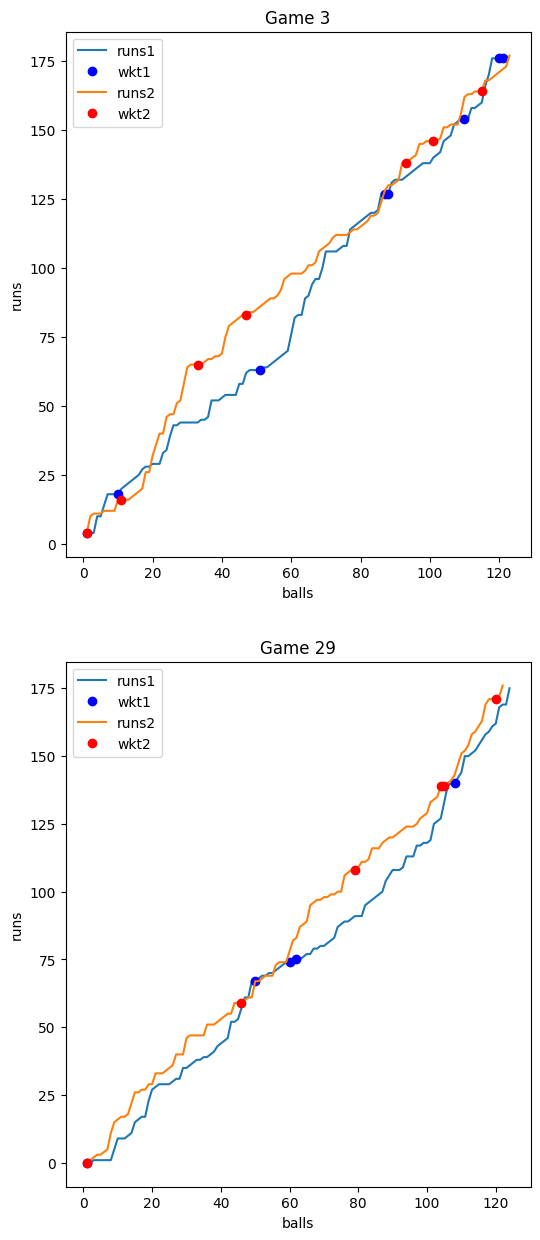

In [10]:
# Generate pair of games between Kolkata Knight Riders and Royal Challengers Bangalore
plot_runs_wickets_multi_game([3,29])

In game 3, The lead go back and forth multiple times up until around ball 20 where the Knight Riders take a substantial lead up until ball 80.  From then on the lead goes back and forth for the rest of the game until the Knight Riders grab thee win right at the end.

In game 29, the Knight Riders take an early lead and hold onto it until they lose their second wicket and around ball 40.  The Challengers hold it for about 15 pitches where the Knight Riders take a substantial lead up until ball 105 where things get close.  The Knight Riders pick up the offense again and are able to beat the about 170 runs put up by the Challengers in inning 1 to sweep the regular season series.

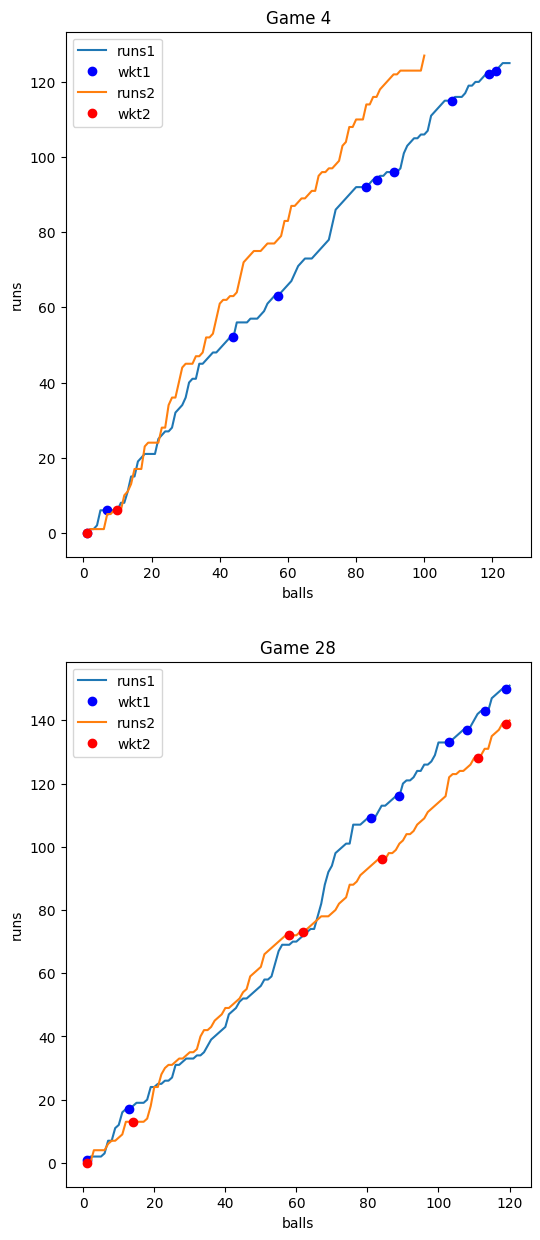

In [11]:
# Generate pair of games between Sunrisers and Rajasthan Royals
plot_runs_wickets_multi_game([4,28])

In game 4, the lead stays close up until about ball 35 where the Sunrisers take a huge lead and never look back.  The Sinrisers win beating the Royals and only needing a little over 100 pitches to do so.

In game 28, the lead goes back and forth multiple times until about ball 70 where the Sunrisers take the lead and carry it to the final ball.  The about 150 runs they put up is enough to beat the Royals by about 20 runs making them 2-0 against the Royals this season.

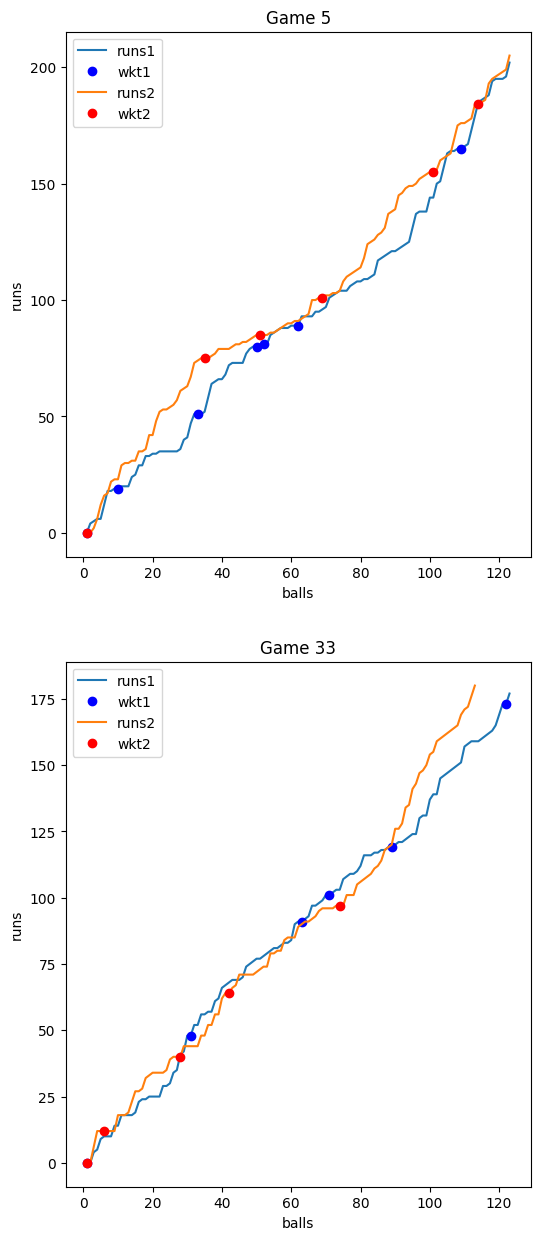

In [12]:
# Generate pair of games between the Chennai Super Kings and Kolkata Knight Riders
plot_runs_wickets_multi_game([5,33])

In game 5, the game stays close until about ball 20 at which point the Kings take a lead until about ball 60.  For the rest of this game the lead goes back and forth multiple times until the Kings overtake the Kinght Riders scoring around 200 runs to give them the win.

In game 33, the game stays close with the lead going back and forth until about ball 90.  At that point the Kings lose their fourth wicket and the Knight Riders take a lead that they never relinqiush.  The Knight Riders win beating the Super Kings in about 115 pitches and salvaging a tie of the season series.